In [235]:
# Utils
# ==============================================================================
import warnings

# Plot
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Data
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification

# Model
# ==============================================================================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Metrics
# ==============================================================================
from sklearn.metrics import accuracy_score

# **Info**
---

**@By**: Steven Bernal

**@Nickname**: Kaiziferr

**@Git**: https://github.com/Kaiziferr

# **Config**
---

In [236]:
sns.set(style="darkgrid")
warnings.simplefilter("ignore")
paleta = sns.color_palette("tab10").as_hex()
random_seed = 12354

# **Context**
---

A synthetic dataset was chosen for this classification problem because it provides a controlled and educational environment, specifically designed to explain the pre-pruning process in decision trees.

Working with real-world datasets usually requires a significant amount of effort in preprocessing tasks such as data cleaning, handling missing values, correcting inconsistencies, and transforming variables. While these steps are essential in any data science workflow, they are outside the scope of this discussion.

# **Goals**
---

- Implement pre-pruning in a decision tree applied to a classification problem using synthetic data.

# **Data**
---

The dataset is generated with 1,000 samples and 10 features. Of these, 6 features are informative and 2 are redundant. No duplicated features are included.

The task is a binary classification problem with two classes. Each class is distributed into two clusters within the feature space.

A label noise rate of 0.08 is introduced, meaning that 8% of the labels are randomly flipped. The class separation is set to 0.8, and the classes are balanced.

A random seed is used to ensure the reproducibility of the dataset.


In [237]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    weights=[0.5, 0.5],
    flip_y=0.08,
    class_sep=0.8,
    random_state=random_seed
)

In [238]:
X = pd.DataFrame(X, columns=[f'A{i}'for i in range(X.shape[1])])

# **Data Split**
---

The dataset is split into training and test sets using a random partition. 20% of the samples are assigned to the test set, while the remaining 80% are used for training.

The split preserves the original structure of the input features and their corresponding labels. A random seed is used to ensure the reproducibility of the partition.

In [239]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_seed
)

# **Model**
---

A baseline Decision Tree is first trained to compute the Cost-Complexity Pruning Path. During this process, Scikit-Learn evaluates the sequence of pruning steps and returns two key outputs:

ccp_alphas, the effective values of the complexity parameter at which the tree structure changes.
impurities, the corresponding total impurity of the terminal nodes after each pruning step.

Together, these values describe the complete pruning path, where each ccp_alpha represents a candidate subtree with a different level of complexity. This information serves as the basis for selecting an appropriate pruning parameter in the following stages of the analysis.

In [240]:
model = DecisionTreeClassifier(random_state=random_seed)
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

The first parameter grid generates the candidate values automatically using np.logspace(). This creates 10 logarithmically spaced values between 10^-5 and 10^-1, providing a broad search across several orders of magnitude. Logarithmic spacing is particularly useful when the optimal value is unknown and may lie anywhere within a wide numerical range.

In [241]:
dic_params_opt_0 = {
    "ccp_alpha": np.logspace(-5, -1, 10)
}

The second parameter grid defines the candidate values manually. Instead of using evenly spaced values on a logarithmic scale, it includes specific ccp_alpha values that are commonly tested in practice. This approach provides greater control over the search space and allows the evaluation to focus on values considered more relevant based on prior knowledge or experimentation.

In [242]:
dic_params_opt_1 = {
    "ccp_alpha": [
        0.00001,
        0.00005,
        0.0001,
        0.0005,
        0.001,
        0.005,
        0.01,
        0.05,
        0.1
    ]
}

The third parameter grid uses the values returned by the Cost-Complexity Pruning Path (cost_complexity_pruning_path). Since these ccp_alpha values are computed directly from the structure of the trained decision tree, every candidate represents a valid pruning point where the tree changes. The last value is excluded (ccp_alphas[:-1]) because it corresponds to pruning the entire tree, leaving only the root node, which is generally not useful for predictive modeling.

In [243]:
dic_params_opt_2 = {
    "ccp_alpha": ccp_alphas[:-1]
}

- A Grid Search is performed independently for each of the three parameter grids. For every search space, a 10-fold cross-validation is used to identify the ccp_alpha value that maximizes the model's accuracy.

- Once the optimal hyperparameter is found, the best estimator is retrieved and evaluated on both the training and test sets. In addition to the cross-validation score, the experiment reports the resulting tree depth, the selected ccp_alpha, and the training and testing accuracies. These metrics provide a comprehensive view of how each search strategy affects both model complexity and predictive performance.

- Finally, the best ccp_alpha obtained from each parameter grid is stored in a dictionary, allowing the results of the three optimization strategies to be compared in the following sections.

In [244]:
best_params = {}


for e, params in enumerate([dic_params_opt_0, dic_params_opt_1, dic_params_opt_2]):
  model_classifier_prepruning = GridSearchCV(
    estimator= model,
    param_grid=params,
    scoring='accuracy',
    cv=10,
    refit=True,
    return_train_score = True
  )
  model_classifier_prepruning.fit(X_train, y_train)
  best_params[f'opt_{e}'] = model_classifier_prepruning.best_params_
  model_classifier_prepruning_best = model_classifier_prepruning.best_estimator_
  print(f"Tree depth: {model_classifier_prepruning_best.get_depth()}")
  print(f'The best score: {model_classifier_prepruning.best_score_:,.2f}')
  print(f'The best params: {model_classifier_prepruning.best_params_}')
  y_predict_prepruning_v1_test = model_classifier_prepruning_best.predict(X_test)
  y_predict_prepruning_v1_train = model_classifier_prepruning_best.predict(X_train)
  print(f'Prediction Data Train: {accuracy_score(y_train, y_predict_prepruning_v1_train)}')
  print(f'Prediction Data Test: {accuracy_score(y_test, y_predict_prepruning_v1_test)}')
  print("\n")


Tree depth: 13
The best score: 0.83
The best params: {'ccp_alpha': np.float64(0.0016681005372000592)}
Prediction Data Train: 0.98
Prediction Data Test: 0.755


Tree depth: 15
The best score: 0.82
The best params: {'ccp_alpha': 1e-05}
Prediction Data Train: 1.0
Prediction Data Test: 0.755


Tree depth: 10
The best score: 0.83
The best params: {'ccp_alpha': np.float64(0.003705882352941177)}
Prediction Data Train: 0.925
Prediction Data Test: 0.75




- Overall, these results illustrate an important characteristic of Cost-Complexity Pruning: different values of ccp_alpha can produce trees of substantially different sizes without significantly affecting predictive performance. In this example, the pruning path generated by Scikit-Learn identified a simpler tree that generalized almost as well as the more complex alternatives, making it an attractive choice when model interpretability and computational efficiency are important.

- To better understand how Cost-Complexity Pruning affects the structure of a decision tree, a separate model is trained for each ccp_alpha value obtained from the pruning path. All resulting trees are stored in a list, making it possible to inspect their structural characteristics in subsequent analyses.

- This collection of models will later be used to compare how the number of nodes and tree depth evolve as the pruning strength increases, providing a clear view of the structural changes introduced by different ccp_alpha values.

In [245]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.07394942052260756


The first visualization shows how the total impurity of the leaf nodes evolves as the effective ccp_alpha increases. The vertical lines indicate the ccp_alpha values selected by the three search strategies, making it possible to compare their positions along the complete pruning path.

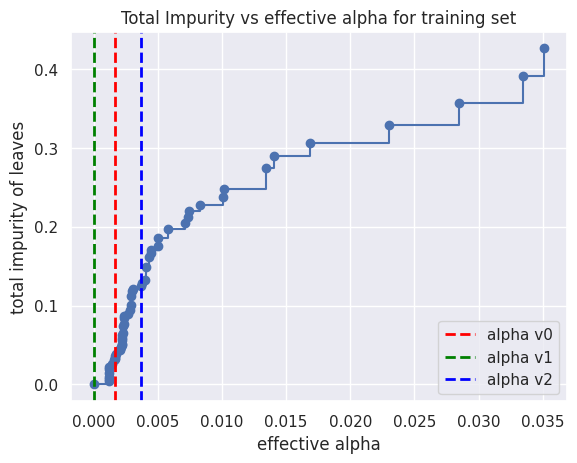

In [246]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.axvline(best_params['opt_0']['ccp_alpha'], color='red', linestyle='--', linewidth=2, label='alpha v0')
ax.axvline(best_params['opt_1']['ccp_alpha'], color='green', linestyle='--', linewidth=2, label='alpha v1')
ax.axvline(best_params['opt_2']['ccp_alpha'], color='blue', linestyle='--', linewidth=2, label='alpha v2')
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.legend()
plt.show()

- The first plot illustrates how the total leaf impurity changes as the effective ccp_alpha increases. Initially, small increases in ccp_alpha produce only minor changes in impurity, indicating that only a few branches are removed during the early stages of pruning. As the pruning process becomes more aggressive, the total impurity increases more rapidly because the remaining leaves must represent larger and more heterogeneous regions of the feature space.
- The three selected ccp_alpha values are located at different points along the pruning path. Option 2 (alpha v1) is positioned near the beginning of the curve, corresponding to a very conservative pruning strategy. Option 0 (alpha v0) lies slightly further along the path, while Option 3 (alpha v2) is associated with a larger ccp_alpha, placing it in a region where pruning is more pronounced and the total leaf impurity is correspondingly higher.
- This visualization clearly illustrates the role of ccp_alpha as a complexity control parameter. As its value increases, the pruning process becomes progressively more aggressive, simplifying the tree while accepting a gradual increase in the impurity of the remaining terminal nodes.

The second visualization illustrates how the number of nodes changes throughout the pruning process. As ccp_alpha increases, branches are progressively removed, producing smaller trees. The selected ccp_alpha values are highlighted to show the complexity of the corresponding pruned trees.

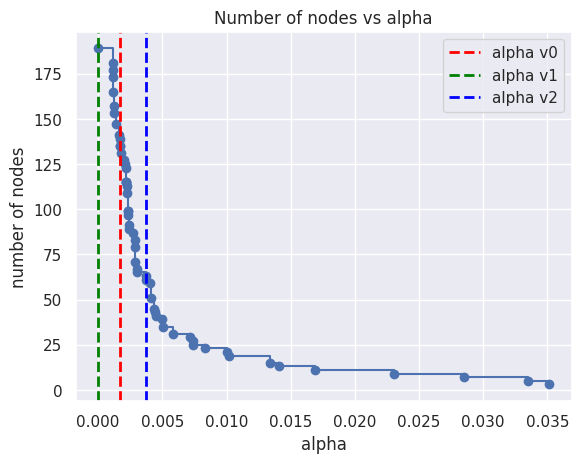

In [247]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots()
ax.plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax.axvline(best_params['opt_0']['ccp_alpha'], color='red', linestyle='--', linewidth=2, label='alpha v0')
ax.axvline(best_params['opt_1']['ccp_alpha'], color='green', linestyle='--', linewidth=2, label='alpha v1')
ax.axvline(best_params['opt_2']['ccp_alpha'], color='blue', linestyle='--', linewidth=2, label='alpha v2')
ax.set_xlabel("alpha")
ax.set_ylabel("number of nodes")
ax.set_title("Number of nodes vs alpha")
plt.legend()
plt.show()
fig.tight_layout()

- The second plot illustrates how the number of nodes changes as ccp_alpha increases. At the beginning of the pruning path, small changes in ccp_alpha remove only a few branches, resulting in a gradual reduction in the number of nodes. As the pruning strength increases, the tree becomes progressively smaller until only a few terminal nodes remain.
- The three selected ccp_alpha values occupy different positions along this curve. Option 2 (alpha v1) is associated with the largest tree, indicating that very little pruning has been applied. Option 0 (alpha v0) removes a larger number of nodes, producing a more compact tree. Finally, Option 3 (alpha v2) leads to the smallest tree among the three selected values, reflecting the most aggressive pruning strategy.
- This visualization highlights one of the main advantages of Cost-Complexity Pruning: relatively small increases in ccp_alpha can substantially reduce the size of the tree. In practice, this means that many branches can be removed without dramatically altering the overall structure of the model, resulting in a simpler and more interpretable decision tree.

The final visualization presents the relationship between tree depth and ccp_alpha. This plot helps illustrate how increasing the pruning strength simplifies the hierarchical structure of the tree, allowing us to compare the depth associated with each selected ccp_alpha.

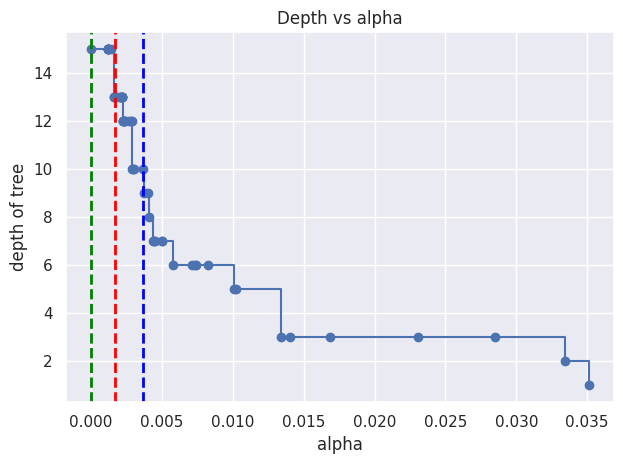

In [248]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax.set_xlabel("alpha")
ax.set_ylabel("depth of tree")
ax.set_title("Depth vs alpha")
ax.axvline(best_params['opt_0']['ccp_alpha'], color='red', linestyle='--', linewidth=2, label='alpha v0')
ax.axvline(best_params['opt_1']['ccp_alpha'], color='green', linestyle='--', linewidth=2, label='alpha v1')
ax.axvline(best_params['opt_2']['ccp_alpha'], color='blue', linestyle='--', linewidth=2, label='alpha v2')
fig.tight_layout()

- The third plot illustrates how the maximum depth of the decision tree changes as ccp_alpha increases. As stronger pruning is applied, the tree becomes progressively shallower. Unlike the number of nodes, however, the depth decreases in discrete steps rather than continuously. This behavior reflects the hierarchical structure of decision trees, where several pruning operations may occur before the longest path from the root to a leaf is shortened.
- The selected ccp_alpha values produce trees with different maximum depths. Option 2 (alpha v1) preserves the deepest tree, with a depth of 15. Option 0 (alpha v0) results in a tree with a depth of 13, while Option 3 (alpha v2) reduces the maximum depth to 10, corresponding to the most compact hierarchical structure among the three alternatives.
- Comparing this figure with the previous one shows that the number of nodes decreases more rapidly than the tree depth. This occurs because many pruning operations remove subtrees from lower levels without immediately affecting the longest path in the tree. As a result, substantial reductions in the number of nodes can occur while the overall depth remains unchanged, until additional pruning eventually shortens the tree's maximum depth.

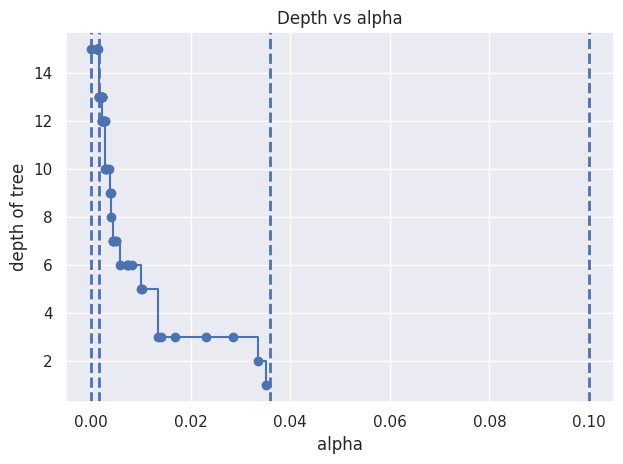

In [257]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax.set_xlabel("alpha")
ax.set_ylabel("depth of tree")
ax.set_title("Depth vs alpha")
ax.axvline(dic_params_opt_0['ccp_alpha'][0],  linestyle='--', linewidth=2, label='alpha v0')
ax.axvline(dic_params_opt_0['ccp_alpha'][5],  linestyle='--', linewidth=2, label='alpha v0')
ax.axvline(dic_params_opt_0['ccp_alpha'][-2], linestyle='--', linewidth=2, label='alpha v1')
ax.axvline(dic_params_opt_0['ccp_alpha'][-1], linestyle='--', linewidth=2, label='alpha v2')
fig.tight_layout()

# **Utils**
---

**@By**: Steven Bernal

**@Nickname**: Kaiziferr

**@Git**: https://github.com/Kaiziferr